In [1]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configuración global de visualización
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

print("Librerías importadas y entorno configurado.")

Librerías importadas y entorno configurado.


In [2]:
# ==============================================================================
# 2. CARGA DE DATOS Y CARACTERÍSTICAS GENERALES
# ==============================================================================
ruta_datos = '/home/alfonso/Documentos/Diplomado_Ciencia_De_Datos/modulo_3/practica_1/M3P1_Metodos_Reduccion/iter_00_cpv2020/conjunto_de_datos/conjunto_de_datos_iter_00CSV20.csv'

# Carga de datos
try:
    df_censo = pd.read_csv(ruta_datos, encoding='utf-8', low_memory=False)
except UnicodeDecodeError:
    df_censo = pd.read_csv(ruta_datos, encoding='latin-1', low_memory=False)

print("--- INFORMACIÓN GENERAL DEL CONJUNTO DE DATOS ORIGINAL ---")
print(f"Número total de filas (incluyendo localidades): {df_censo.shape[0]}")
print(f"Número total de columnas: {df_censo.shape[1]}")

# Mostrar las primeras filas y los tipos de datos de las primeras 10 columnas
display(df_censo.head(3))

--- INFORMACIÓN GENERAL DEL CONJUNTO DE DATOS ORIGINAL ---
Número total de filas (incluyendo localidades): 195662
Número total de columnas: 286


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,...,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
0,0,Total nacional,0,Total nacional,0,Total nacional,NaN,NaN,NaN,126014024,...,30775898,18307193,15211306,6616141,4047100,1788552,3170894,15108204,852871,*
1,0,Total nacional,0,Total nacional,9998,Localidades de una vivienda,NaN,NaN,NaN,250354,...,47005,8385,18981,1732,1113,12775,14143,51293,7154,*
2,0,Total nacional,0,Total nacional,9999,Localidades de dos viviendas,NaN,NaN,NaN,147125,...,25581,5027,11306,971,708,8247,10065,29741,5283,*


In [3]:
# ==============================================================================
# 3. FILTRADO, SELECCIÓN Y LIMPIEZA DE DATOS
# ==============================================================================
# 1. Filtrar solo los totales municipales
df_municipios = df_censo[df_censo['NOM_LOC'] == 'Total del Municipio'].copy()

# 2. Selección de variables de marginación
cols_identificacion = ['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'POBTOT']
cols_marginacion = ['P15YM_AN', 'P15PRI_IN', 'PSINDER', 'VPH_PISOTI', 'VPH_NODREN', 'VPH_S_ELEC', 'VPH_AGUAFV']

df_modelo = df_municipios[cols_identificacion + cols_marginacion].copy()

# 3. Limpieza de caracteres no numéricos ('*' o 'N/D' del INEGI)
columnas_numericas = cols_marginacion + ['POBTOT']
for col in columnas_numericas:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors='coerce')

df_modelo = df_modelo.dropna()

print("--- RESULTADO DEL FILTRADO ---")
print(f"Total de municipios a analizar: {df_modelo.shape[0]}")
print("\nConteo de valores nulos post-limpieza:")
print(df_modelo[cols_marginacion].isnull().sum())

--- RESULTADO DEL FILTRADO ---
Total de municipios a analizar: 2469

Conteo de valores nulos post-limpieza:
P15YM_AN      0
P15PRI_IN     0
PSINDER       0
VPH_PISOTI    0
VPH_NODREN    0
VPH_S_ELEC    0
VPH_AGUAFV    0
dtype: int64


In [4]:
# ==============================================================================
# 4. INGENIERÍA DE CARACTERÍSTICAS Y DESCRIPCIÓN ESTADÍSTICA
# ==============================================================================
# Convertir valores absolutos a porcentajes para estandarizar la comparativa entre municipios
df_modelo['PCT_ANALFABETISMO'] = (df_modelo['P15YM_AN'] / df_modelo['POBTOT']) * 100
df_modelo['PCT_SIN_PRIMARIA']  = (df_modelo['P15PRI_IN'] / df_modelo['POBTOT']) * 100
df_modelo['PCT_SIN_SALUD']     = (df_modelo['PSINDER']   / df_modelo['POBTOT']) * 100
df_modelo['PCT_PISO_TIERRA']   = (df_modelo['VPH_PISOTI']/ df_modelo['POBTOT']) * 100
df_modelo['PCT_SIN_DRENAJE']   = (df_modelo['VPH_NODREN']/ df_modelo['POBTOT']) * 100
df_modelo['PCT_SIN_LUZ']       = (df_modelo['VPH_S_ELEC']/ df_modelo['POBTOT']) * 100
df_modelo['PCT_SIN_AGUA']      = (df_modelo['VPH_AGUAFV']/ df_modelo['POBTOT']) * 100

variables_pca = [
    'PCT_ANALFABETISMO', 'PCT_SIN_PRIMARIA', 'PCT_SIN_SALUD', 
    'PCT_PISO_TIERRA', 'PCT_SIN_DRENAJE', 'PCT_SIN_LUZ', 'PCT_SIN_AGUA'
]

print("--- ESTADÍSTICA DESCRIPTIVA DE LAS VARIABLES DE MARGINACIÓN (%) ---")
# Mostrar media, mínimos, máximos y cuartiles para entender la dispersión
display(df_modelo[variables_pca].describe().round(2))

--- ESTADÍSTICA DESCRIPTIVA DE LAS VARIABLES DE MARGINACIÓN (%) ---


,PCT_ANALFABETISMO,PCT_SIN_PRIMARIA,PCT_SIN_SALUD,PCT_PISO_TIERRA,PCT_SIN_DRENAJE,PCT_SIN_LUZ,PCT_SIN_AGUA
count,2469.00,2469.00,2469.00,2469.00,2469.00,2469.00,2469.00
mean,7.18,10.80,24.13,2.11,3.71,0.50,1.67
std,5.13,4.38,10.82,2.25,5.14,0.73,2.42
min,0.12,0.28,1.04,0.00,0.00,0.00,0.00
25%,3.25,7.71,16.23,0.51,0.62,0.15,0.29
50%,5.94,10.63,22.63,1.31,1.69,0.32,0.73
75%,9.61,13.57,30.62,2.95,4.33,0.60,1.99
max,34.61,28.13,83.86,17.41,31.15,12.38,23.76


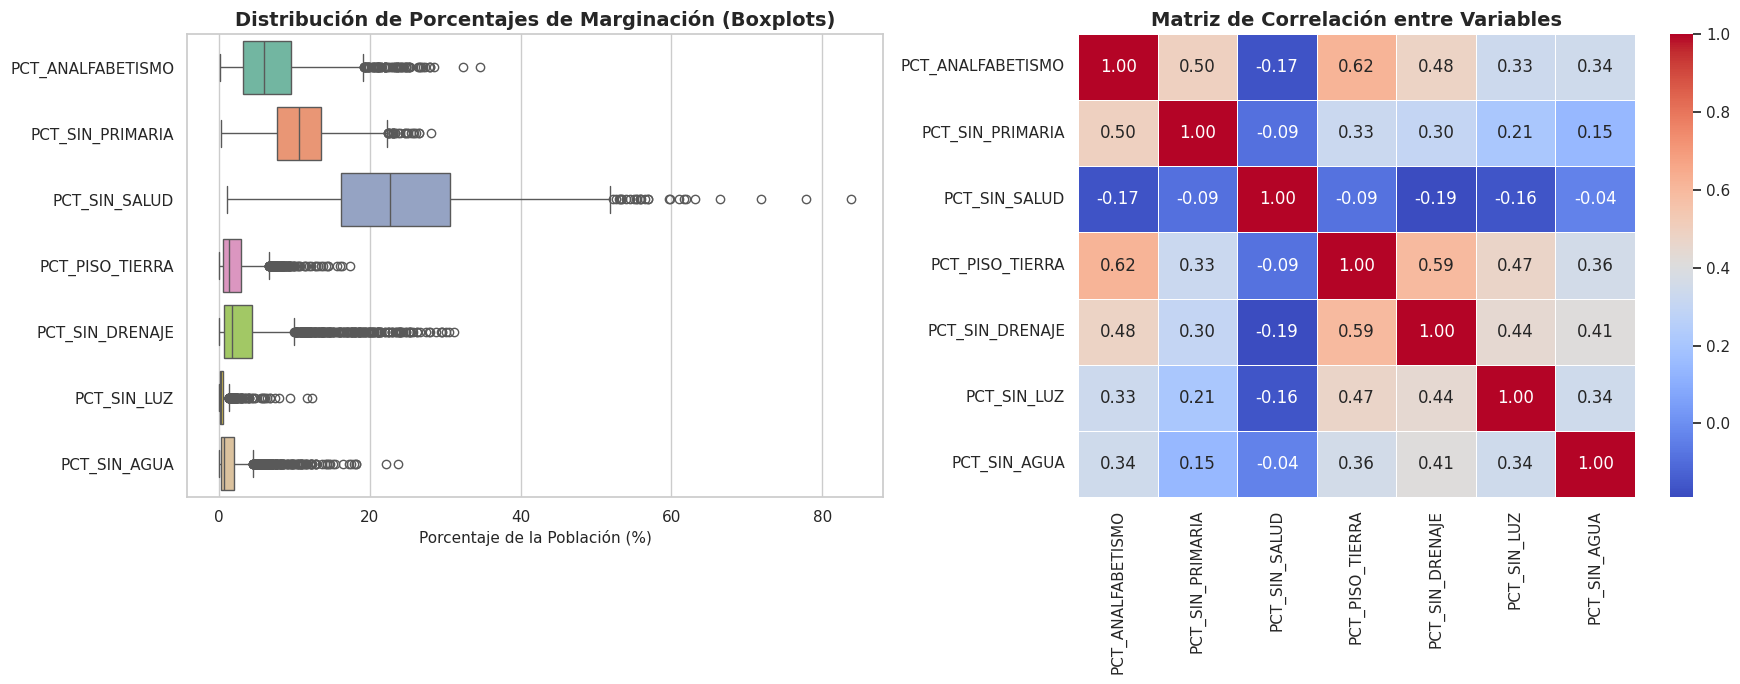

In [5]:
# ==============================================================================
# 5. ANÁLISIS EXPLORATORIO VISUAL (EDA)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Distribución (Boxplot) de las variables
# Nos permite ver qué variables tienen más valores atípicos (outliers)
sns.boxplot(data=df_modelo[variables_pca], orient="h", palette="Set2", ax=axes[0])
axes[0].set_title('Distribución de Porcentajes de Marginación (Boxplots)', fontweight='bold')
axes[0].set_xlabel('Porcentaje de la Población (%)')

# Gráfico 2: Matriz de Correlación
# Fundamental antes de PCA: Si existe alta correlación, PCA es el método ideal.
matriz_corr = df_modelo[variables_pca].corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[1])
axes[1].set_title('Matriz de Correlación entre Variables', fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
# ==============================================================================
# 6. ESTANDARIZACIÓN Y MODELADO PCA
# ==============================================================================
X = df_modelo[variables_pca]

# Estandarización de variables (Z-score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicación de PCA
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(X_scaled)

# Guardar resultados
df_modelo['Componente_1'] = componentes[:, 0]
df_modelo['Componente_2'] = componentes[:, 1]

var_exp = pca.explained_variance_ratio_
print("--- RESUMEN DEL MODELO PCA ---")
print(f"Varianza retenida por Componente 1 (Índice General): {var_exp[0]*100:.2f}%")
print(f"Varianza retenida por Componente 2:                  {var_exp[1]*100:.2f}%")
print(f"Varianza total rescatada en 2 Dimensiones:           {sum(var_exp)*100:.2f}%")

# Crear un DataFrame con las cargas (pesos) de cada variable original en el Componente 1
pesos_pca = pd.DataFrame(
    pca.components_[0], 
    index=variables_pca, 
    columns=['Peso_en_C1']
).sort_values(by='Peso_en_C1', ascending=False)

print("\n¿Qué variables impactan más en el Índice de Marginación (Componente 1)?")
display(pesos_pca)

--- RESUMEN DEL MODELO PCA ---
Varianza retenida por Componente 1 (Índice General): 43.66%
Varianza retenida por Componente 2:                  14.08%
Varianza total rescatada en 2 Dimensiones:           57.74%

¿Qué variables impactan más en el Índice de Marginación (Componente 1)?


,Peso_en_C1
PCT_PISO_TIERRA,0.466730
PCT_ANALFABETISMO,0.451251
PCT_SIN_DRENAJE,0.449785
PCT_SIN_LUZ,0.376972
PCT_SIN_AGUA,0.334292
PCT_SIN_PRIMARIA,0.317277
PCT_SIN_SALUD,-0.147326


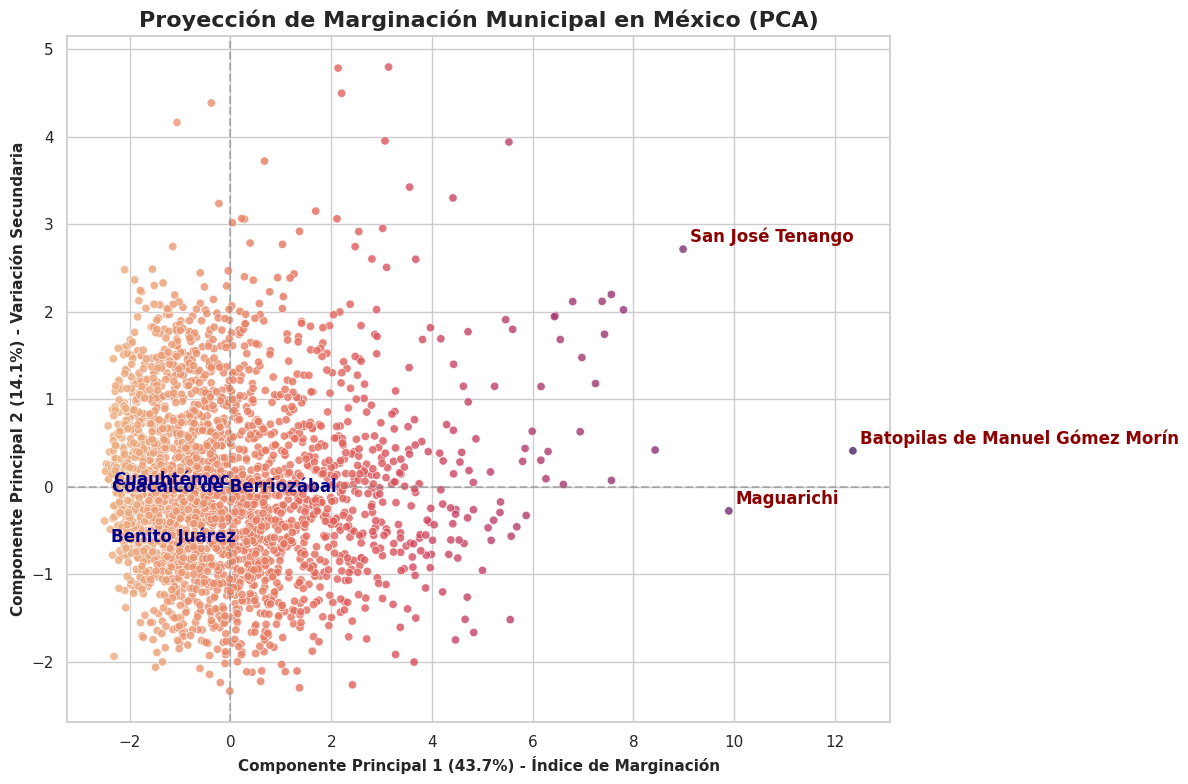

In [7]:
# ==============================================================================
# 7. PROYECCIÓN EN DIMENSIÓN REDUCIDA (RESULTADO FINAL)
# ==============================================================================
plt.figure(figsize=(12, 8))

scatter = sns.scatterplot(
    x='Componente_1', y='Componente_2', 
    data=df_modelo, hue='Componente_1',
    palette='flare', alpha=0.8, legend=False
)

plt.title('Proyección de Marginación Municipal en México (PCA)', fontweight='bold', fontsize=16)
plt.xlabel(f'Componente Principal 1 ({var_exp[0]*100:.1f}%) - Índice de Marginación', fontweight='bold')
plt.ylabel(f'Componente Principal 2 ({var_exp[1]*100:.1f}%) - Variación Secundaria', fontweight='bold')
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)

# Etiquetar los 3 municipios con mayor marginación (valores más altos en C1)
top_3_marg = df_modelo.nlargest(3, 'Componente_1')
for _, row in top_3_marg.iterrows():
    plt.annotate(row['NOM_MUN'], (row['Componente_1'], row['Componente_2']), 
                 xytext=(5, 5), textcoords='offset points', color='darkred', weight='bold')

# Etiquetar los 3 municipios con menor marginación (valores más bajos en C1)
top_3_desarr = df_modelo.nsmallest(3, 'Componente_1')
for _, row in top_3_desarr.iterrows():
    plt.annotate(row['NOM_MUN'], (row['Componente_1'], row['Componente_2']), 
                 xytext=(5, -15), textcoords='offset points', color='darkblue', weight='bold')

plt.tight_layout()
plt.show()

In [8]:
# ==============================================================================
# DESCUBRIENDO EL COMPONENTE 2
# ==============================================================================
pesos_pca2 = pd.DataFrame(
    pca.components_[1], 
    index=variables_pca, 
    columns=['Peso_en_C2']
).sort_values(by='Peso_en_C2', ascending=False)

print("¿Qué variables definen el Componente 2 (Eje Y)?")
display(pesos_pca2)

¿Qué variables definen el Componente 2 (Eje Y)?


,Peso_en_C2
PCT_SIN_SALUD,0.917609
PCT_SIN_AGUA,0.347521
PCT_PISO_TIERRA,0.135296
PCT_SIN_DRENAJE,0.018957
PCT_SIN_LUZ,0.017793
PCT_ANALFABETISMO,-0.041100
PCT_SIN_PRIMARIA,-0.128658
